In [52]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.OU import analyze_spreads

In [53]:
cointegrated_pairs = pd.read_parquet("data/processed/cointegrated_pairs.parquet")

with open("data/processed/spreads.pkl", "rb") as f:
    spreads = pickle.load(f)

print(f"cointegrated pairs: {len(cointegrated_pairs)}")

cointegrated pairs: 446


In [54]:
spread_statistics = analyze_spreads(spreads)
print(len(spreads))

446


In [55]:
spread_statistics.head()

,pair,dependent,independent,mean,std,min spread,max spread,theta,half_life,expected_convergence,hurst,current z
0,V-MA,V,MA,-4.110665e-15,0.024864,-0.067772,0.081673,0.039095,17.729867,53.189602,0.360835,-0.946981
1,NWS-NWSA,NWS,NWSA,-3.981402e-16,0.017107,-0.116219,0.036461,0.038747,17.888873,53.666619,0.285465,1.000233
2,MLM-VMC,MLM,VMC,1.383114e-14,0.049987,-0.182892,0.273007,0.038179,18.155329,54.465986,0.283777,-0.970178
3,HLT-AXP,HLT,AXP,-2.222718e-15,0.068528,-0.268255,0.190885,0.035402,19.579342,58.738026,0.313413,0.338066
4,GOOGL-GOOG,GOOGL,GOOG,2.234584e-15,0.007476,-0.033790,0.018120,0.035110,19.742112,59.226335,0.353314,-0.630847


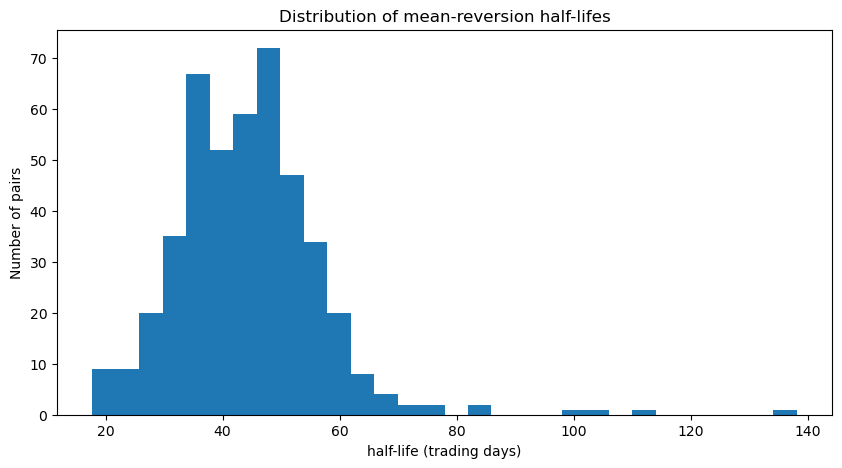

In [56]:
plt.figure(figsize=(10,5))

plt.hist(spread_statistics["half_life"], bins=30)
plt.xlabel("half-life (trading days)")
plt.ylabel("Number of pairs")
plt.title("Distribution of mean-reversion half-lifes")

plt.show()

In [57]:
spread_statistics["half_life"].describe()

count    446.000000
mean      44.399598
std       12.497638
min       17.729867
25%       36.092476
50%       43.822995
75%       50.642348
max      138.091392
Name: half_life, dtype: float64

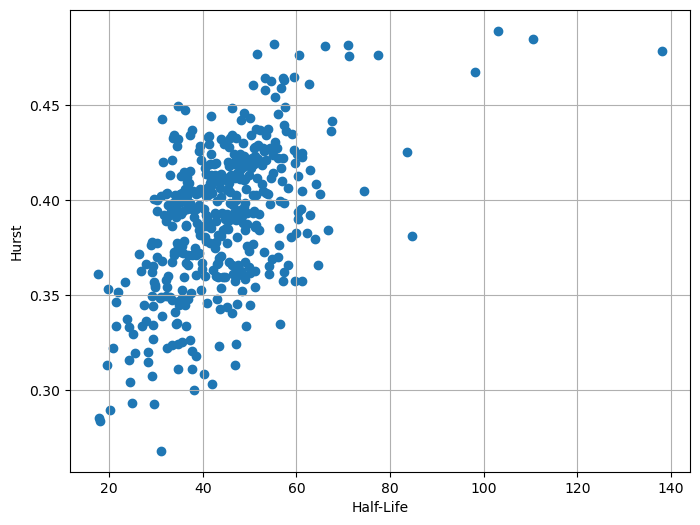

In [58]:
plt.figure(figsize=(8,6))

plt.scatter(
    spread_statistics["half_life"],
    spread_statistics["hurst"]
)

plt.xlabel("Half-Life")

plt.ylabel("Hurst")

plt.grid(True)

plt.show()

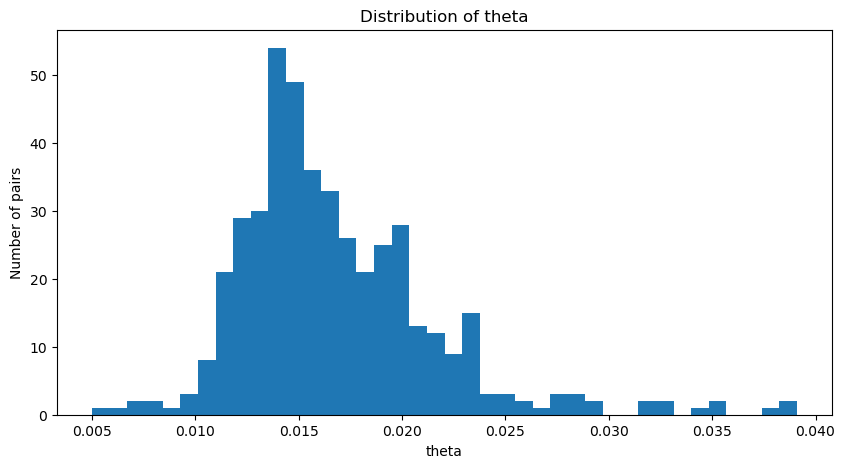

In [59]:
plt.figure(figsize=(10,5))

plt.hist(spread_statistics["theta"], bins=40)
plt.xlabel("theta")
plt.ylabel("Number of pairs")
plt.title("Distribution of theta")

plt.show()

In [60]:
pair = ("SHW", "HD")

spread = spreads[pair]
spread = spread.dropna().iloc[-504:]

print(len(spread))

504


In [61]:
print(spread_statistics[:40])

          pair dependent independent          mean       std  min spread  \
0         V-MA         V          MA -4.110665e-15  0.024864   -0.067772   
1     NWS-NWSA       NWS        NWSA -3.981402e-16  0.017107   -0.116219   
2      MLM-VMC       MLM         VMC  1.383114e-14  0.049987   -0.182892   
3      HLT-AXP       HLT         AXP -2.222718e-15  0.068528   -0.268255   
4   GOOGL-GOOG     GOOGL        GOOG  2.234584e-15  0.007476   -0.033790   
5       SHW-HD       SHW          HD -1.124588e-14  0.056705   -0.156361   
6       URI-MS       URI          MS -4.401002e-15  0.087648   -0.277321   
7      LYV-AXP       LYV         AXP -3.641582e-15  0.094060   -0.308480   
8     SPGI-MCO      SPGI         MCO -1.057331e-15  0.040006   -0.168375   
9      MDLZ-PG      MDLZ          PG -7.521745e-15  0.043512   -0.141182   
10     PEP-HSY       PEP         HSY -9.217565e-15  0.041325   -0.120839   
11     ADI-CDW       ADI         CDW  9.291790e-15  0.068122   -0.218436   
12     KEY-C

In [62]:
top_40_pairs = spread_statistics[:40]

top_40_pairs.to_parquet("data/processed/ou_results.parquet", index = False)